### Con este notebook, queremos comenzar demostrando rigor de los datos


Preparamos los datos:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os


def cargar_todo(anios):
    dfs = []
    for anio in anios:
        ruta = f'..//data//viajes_cartagena_murcia_{anio}.parquet'
        if os.path.exists(ruta):
            df = pd.read_parquet(ruta)
            # Limpieza y conversión
            df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')
            df['periodo'] = df['periodo'].astype(int)
            df['viajes'] = pd.to_numeric(df['viajes'], errors='coerce').fillna(0)
            df['mes'] = df['fecha'].dt.month
            df['anio'] = anio
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def cargar_y_preparar_datos(ruta_parquet):
    try:
        df = pd.read_parquet(ruta_parquet)
        print("Realizado existosamente")
    except Exception as e:
        print(f"Error: {e}")
    
    # Asumimos que 'fecha' se puede pasar a datetime
    df['fecha'] = pd.to_datetime(df['fecha'])
    
    # que las horas esten en formsto numerico
    df['periodo'] = df['periodo'].astype(int)
    
    # convertimos la columna viajes a numerico y si hay algun error lo convertimos en null y rellenamos los nul con 0
    df['viajes'] = pd.to_numeric(df['viajes'], errors='coerce').fillna(0)

    
    # Extraemos el mes (1-12) y el día de la semana (0=Lunes, 6=Domingo)
    df['mes'] = df['fecha'].dt.month
    df['dia_semana'] = df['fecha'].dt.dayofweek
    
    return df

### **Gráfico por horas**

In [2]:
def graficar_comparativa_horaria(df):
    # Agrupamos por año y periodo
    ho_anio = df.groupby(['anio', 'periodo'])['viajes'].sum().reset_index()
    
    plt.figure(figsize=(12, 6))
    # Usamos 'hue' para que Seaborn asigne un color a cada año
    sns.lineplot(data=ho_anio, x='periodo', y='viajes', hue='anio', 
                 palette='viridis', marker='o', linewidth=2)
    
    plt.title('Comparativa Interanual: Distribución de Viajes por Hora', fontsize=14, weight='bold')
    plt.xlabel('Hora del Día')
    plt.ylabel('Suma de Viajes')
    plt.xticks(range(0, 24))
    plt.legend(title='Año')
    plt.tight_layout()
    plt.show()


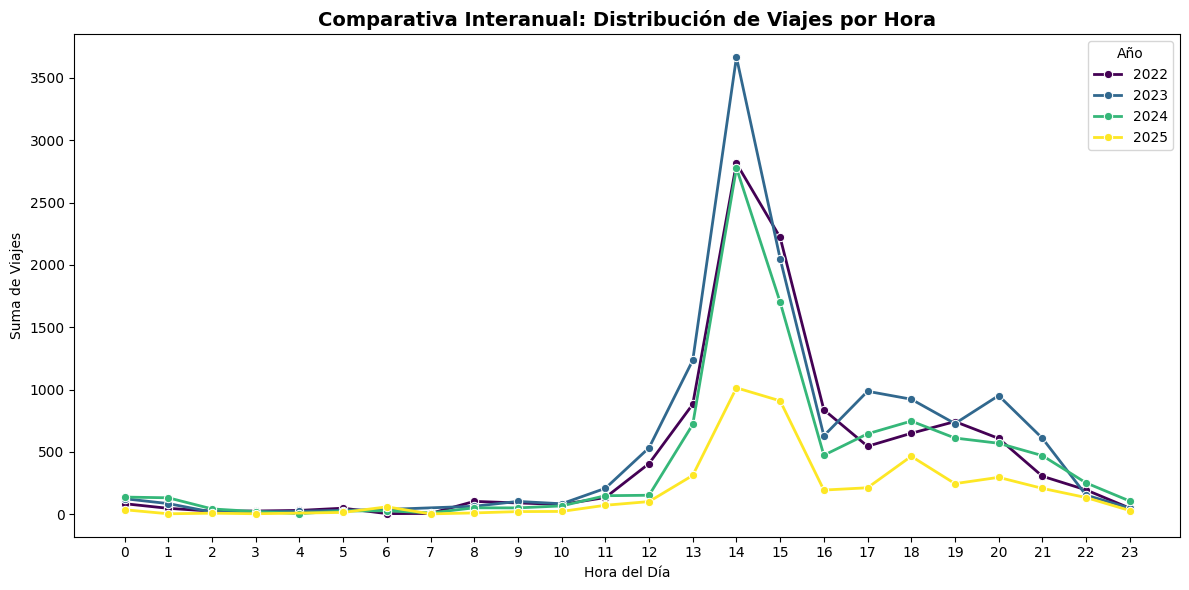

In [3]:
df_total = cargar_todo([2022, 2023, 2024, 2025])
graficar_comparativa_horaria(df_total)

Vemos que se mantiene el pico, desde las 12 hasta las 15-16, comeinzan todas las salidas hacia cartagena lo cual, es un índice muy correto, pues la mayoría de gente que sale de clase es en ese intervalo 

### **Gráfico semanal**

In [4]:
def graficar_semanales(df):
    anios_disponibles = sorted(df['anio'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
    axes = axes.flatten()
    
    dias_nombres = {0:'Lun', 1:'Mar', 2:'Mie', 3:'Jue', 4:'Vie', 5:'Sab', 6:'Dom'}
    
    for i, anio in enumerate(anios_disponibles):
        if i < 4:
            df_anio = df[df['anio'] == anio].copy()
            df_anio['dia_semana'] = df_anio['fecha'].dt.dayofweek
            semanal = df_anio.groupby('dia_semana')['viajes'].sum().reset_index()
            semanal['dia_nombre'] = semanal['dia_semana'].map(dias_nombres)
            
            sns.barplot(data=semanal, x='dia_nombre', y='viajes', ax=axes[i], palette='magma')
            axes[i].set_title(f'Flujo Semanal {anio}', fontsize=12, weight='bold')
            axes[i].set_xlabel('')
            axes[i].set_ylabel('Suma de Viajes')

    plt.suptitle('Evolución del Flujo Semanal (2022-2025)', fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\2515219311.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=semanal, x='dia_nombre', y='viajes', ax=axes[i], palette='magma')
C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\2515219311.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=semanal, x='dia_nombre', y='viajes', ax=axes[i], palette='magma')
C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\2515219311.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=semanal, x='dia_nombre', y='viajes', ax=axes[i], palette='mag

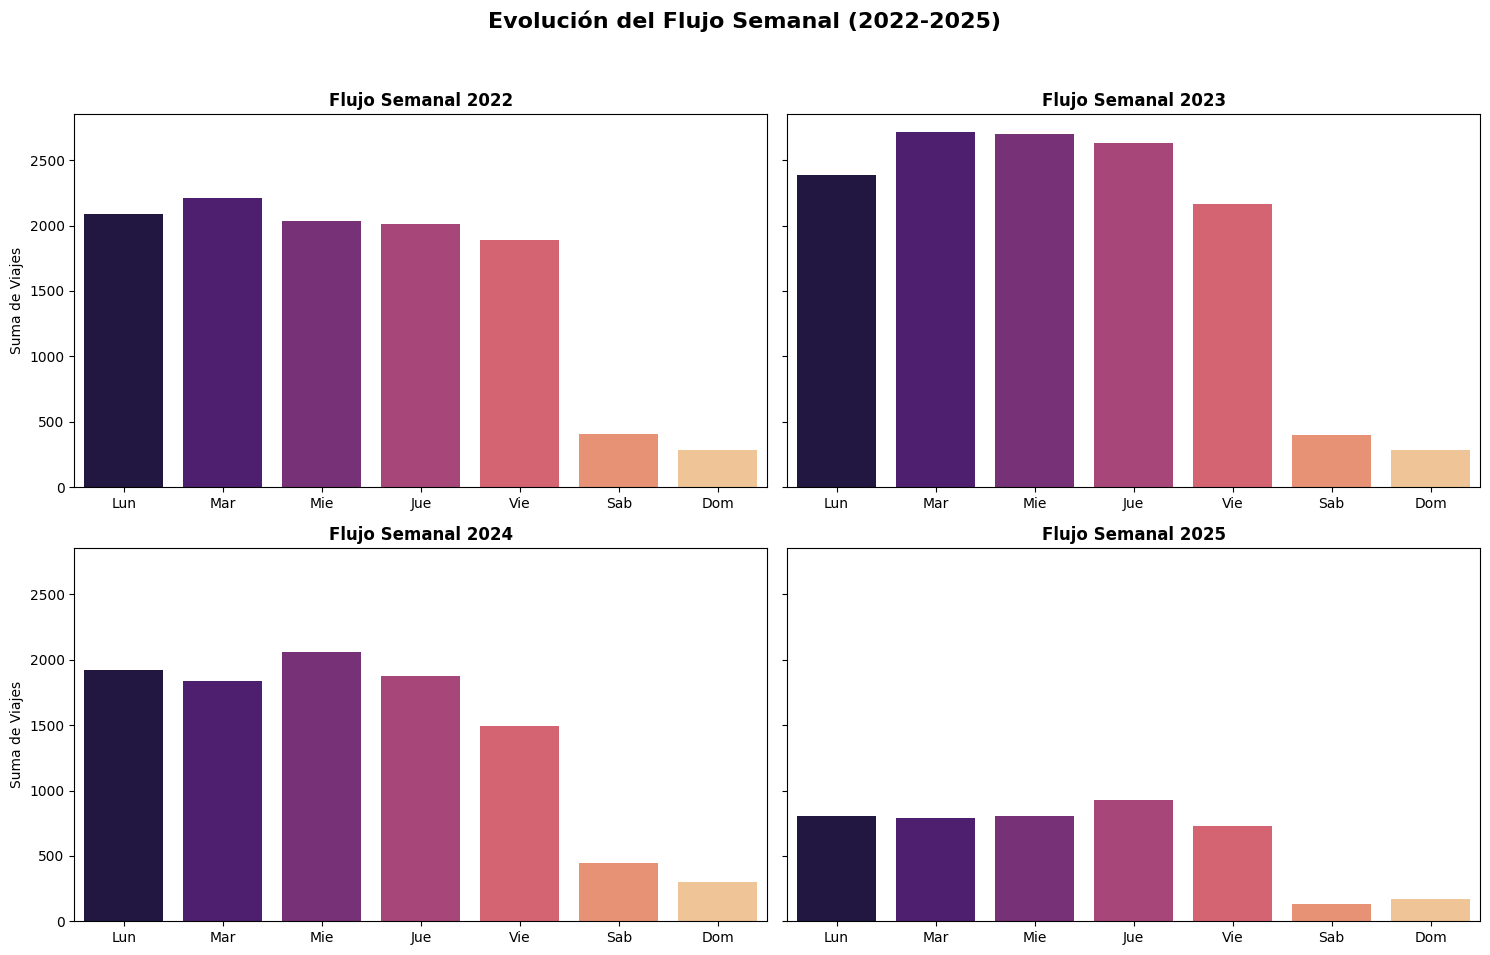

In [5]:
df_total = cargar_todo([2022, 2023, 2024, 2025])
graficar_semanales(df_total)

Todos guardan la misma estrucutra lo cual es muy positivo 

### **Gráfico  anual**

In [6]:
def graficar_caida_verano(df, anio):
    flujo_mensual = df.groupby('mes')['viajes'].sum().reset_index()
    
    meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 
                     7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    flujo_mensual['mes_nombre'] = flujo_mensual['mes'].map(meses_nombres)
    
    plt.figure()
    sns.barplot(data=flujo_mensual, x='mes_nombre', y='viajes', palette='viridis')
    
    plt.title(f'Volumen de Viajes por Mes - Efecto Verano ({anio})', fontsize=14, weight='bold')
    plt.xlabel('Mes')
    plt.ylabel('Volumen Total de Viajes')
    plt.tight_layout()
    plt.show()

In [7]:
def graficar_anuales(df):
    """
    Genera un panel 2x2 con el flujo mensual (efecto verano) para los 4 años.
    """
    anios_disponibles = sorted(df['anio'].unique())
    # sharey=True asegura que todos los gráficos usen la misma escala vertical para comparar bien
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
    axes = axes.flatten()
    
    meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 
                     7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
    
    for i, anio in enumerate(anios_disponibles):
        if i < 4:
            # Filtramos el año correspondiente
            df_anio = df[df['anio'] == anio].copy()
            
            # Agrupamos por mes y calculamos la suma
            flujo_mensual = df_anio.groupby('mes')['viajes'].sum().reset_index()
            # Mapeamos los números a nombres de meses
            flujo_mensual['mes_nombre'] = flujo_mensual['mes'].map(meses_nombres)
            
            # Dibujamos en el eje (ax) correspondiente
            sns.barplot(data=flujo_mensual, x='mes_nombre', y='viajes', ax=axes[i], palette='crest')
            
            # Títulos y limpieza visual
            axes[i].set_title(f'Flujo Mensual {anio}', fontsize=12, weight='bold')
            axes[i].set_xlabel('')
            
            # Solo ponemos la etiqueta Y en los gráficos de la izquierda para no saturar
            if i % 2 == 0:
                axes[i].set_ylabel('Suma de Viajes')
            else:
                axes[i].set_ylabel('')
                
            # Rotar los nombres de los meses para mejor legibilidad
            axes[i].tick_params(axis='x', rotation=45)

    plt.suptitle('Evolución Interanual del Flujo Mensual (2022-2025)', fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\3545089410.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flujo_mensual, x='mes_nombre', y='viajes', ax=axes[i], palette='crest')
C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\3545089410.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flujo_mensual, x='mes_nombre', y='viajes', ax=axes[i], palette='crest')
C:\Users\beltr\AppData\Local\Temp\ipykernel_2116\3545089410.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flujo_mensual, x='mes_nombre', y='viajes', ax=axe

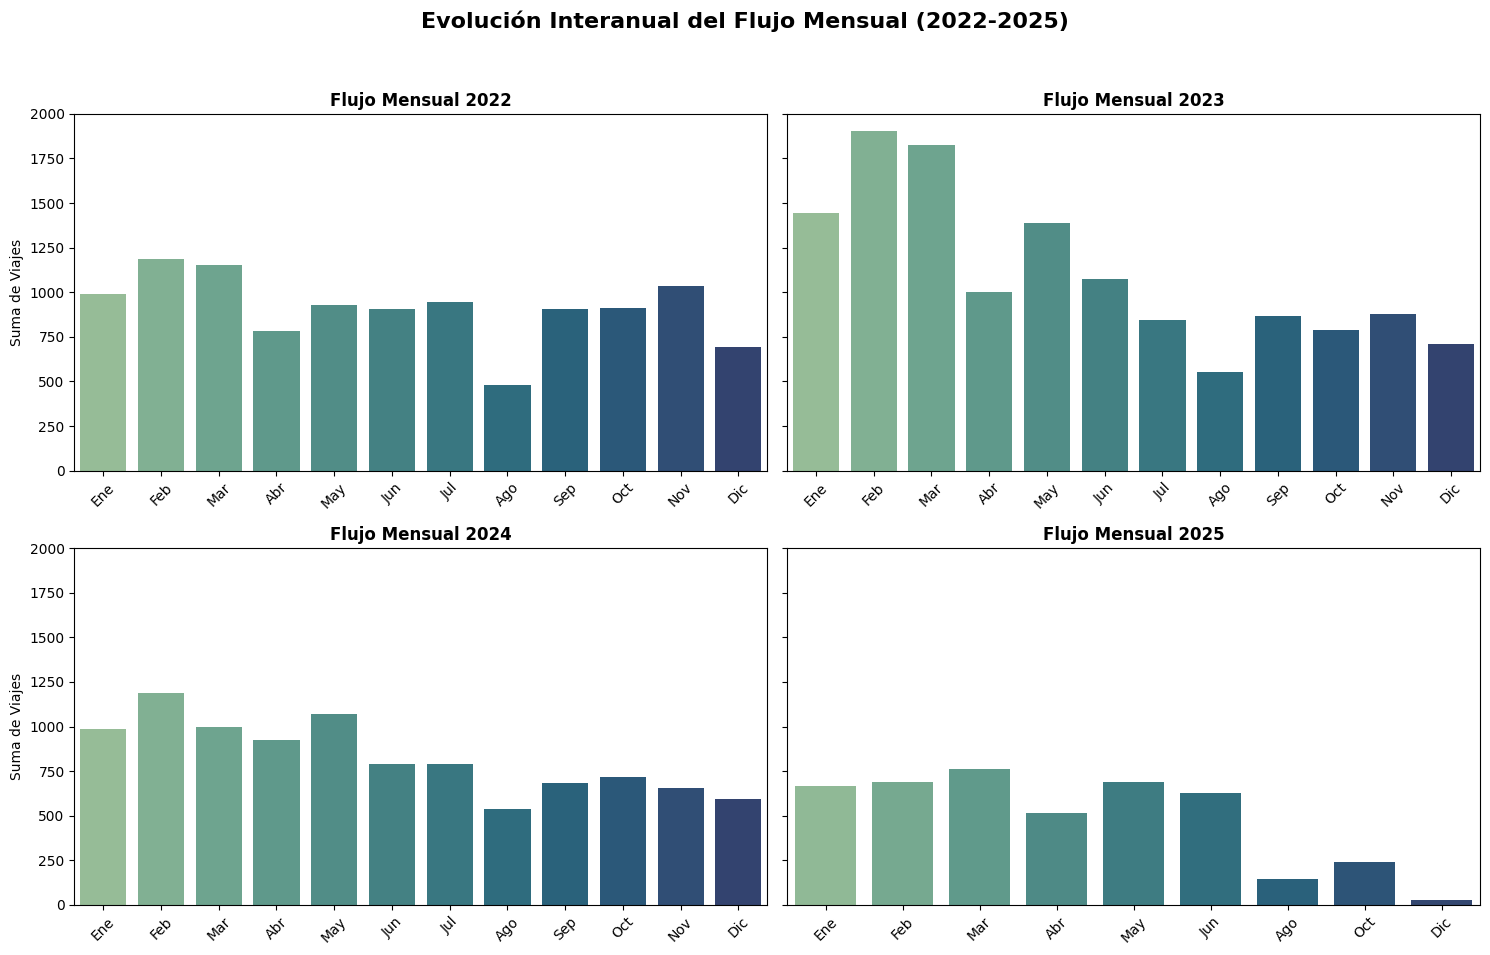

In [8]:
df_total = cargar_todo([2022, 2023, 2024, 2025])
graficar_anuales(df_total)

Obtenemos resultados muy parecidos con los dados de murcia a cartegan , lo que indica que hay cohesióne en los datos.

##### Podemos encontrar caidas extrañas, con lo que accedemos a un mes concreto para ver como ha sido su flujo:

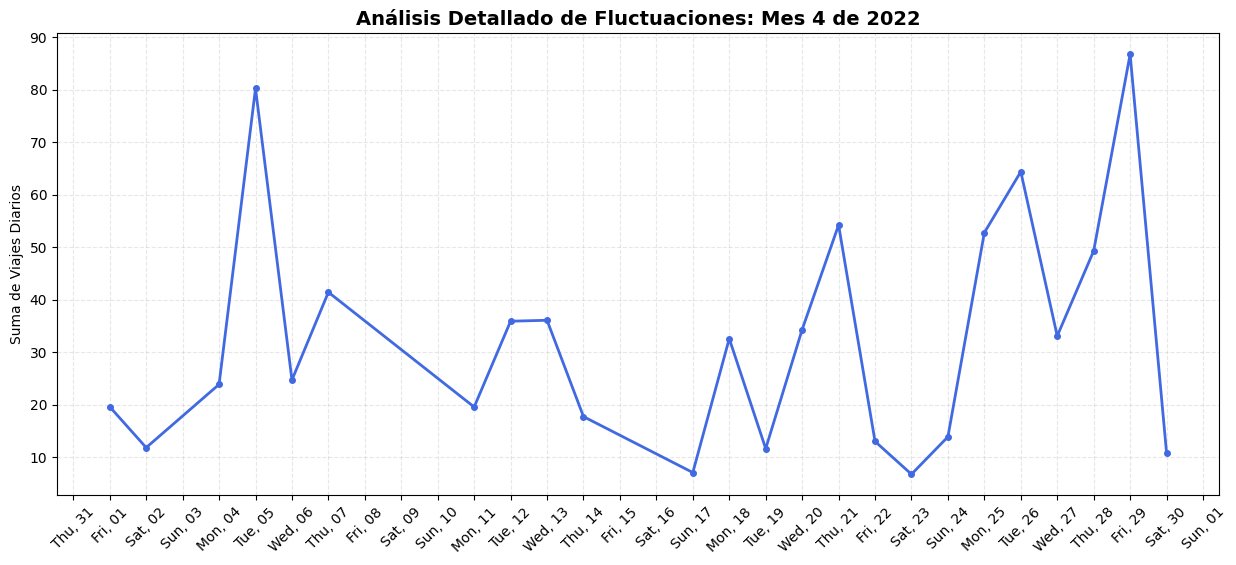

In [9]:
def estudio_detallado_mes(df, anio_objetivo, mes_objetivo):
    # Filtramos por el año y mes que queremos analizar
    filtro = df[(df['anio'] == anio_objetivo) & (df['fecha'].dt.month == mes_objetivo)]
    
    # Agrupamos por día exacto para ver la fluctuación diaria
    agrupacion_dias = filtro.groupby('fecha')['viajes'].sum().reset_index()
    
    plt.figure(figsize=(15, 6))
    plt.plot(agrupacion_dias['fecha'], agrupacion_dias['viajes'], 
             color='royalblue', linewidth=2, marker='.', markersize=8)

    ax = plt.gca()

    # Configuramos el localizador para que marque cada día del mes
    ax.xaxis.set_major_locator(mdates.DayLocator())
    # Formateador: Día de la semana (abreviado) y número de día
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a, %d'))

    plt.xticks(rotation=45)
    plt.title(f'Análisis Detallado de Fluctuaciones: Mes {mes_objetivo} de {anio_objetivo}', 
              fontsize=14, weight='bold')
    plt.ylabel('Suma de Viajes Diarios')
    plt.grid(True, alpha=0.3, linestyle='--')
    

    plt.show()

estudio_detallado_mes(df_total, 2022, 4)

Aquí el estudio se respeta mucho más, que la semana snta y fiesta de primavera, apenas hay llegadas a murcia , comparado con la semana siguiente que el flujo se retoma de manera considerable